In [1]:
import numpy as np
import tensorflow as tf
from keras.optimizers import Adam
from vae_words_model import WordVAE, encode_word, decode_output, MAX_LEN, VOCAB_SIZE

In [2]:
# ---------------------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------------------
LATENT_DIM = 16
EPOCHS = 30
BATCH_SIZE = 256

In [3]:
# ---------------------------------------------------------------------------
# Load & preprocess words
# ---------------------------------------------------------------------------
print("Loading word list …")
with open("/usr/share/dict/words") as f:
    raw_words = [w.strip() for w in f]

Loading word list …


In [4]:
# Keep only all-alpha words up to MAX_LEN characters
words = [w.lower() for w in raw_words if w.isalpha() and 1 <= len(w) <= MAX_LEN]
print(f"  {len(words):,} words after filtering (max length {MAX_LEN})")

  198,537 words after filtering (max length 12)


In [5]:
# Encode to flat one-hot vectors  shape: (N, MAX_LEN * VOCAB_SIZE)
print("Encoding words …")
x_words = np.array([encode_word(w) for w in words], dtype="float32")
print(f"  Dataset shape: {x_words.shape}")

Encoding words …
  Dataset shape: (198537, 324)


In [6]:
# Train / validation split (90 / 10)
split = int(len(x_words) * 0.9)
x_train, x_val = x_words[:split], x_words[split:]

In [7]:
# ---------------------------------------------------------------------------
# Build & train model
# ---------------------------------------------------------------------------
vae = WordVAE(latent_dim=LATENT_DIM)
vae.compile(optimizer=Adam(learning_rate=0.001))

In [8]:
print(f"\nTraining WordVAE  (latent_dim={LATENT_DIM}, epochs={EPOCHS}) …")
history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, x_val),
)


Training WordVAE  (latent_dim=16, epochs=30) …
Epoch 1/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - kl_loss: 2.5214 - loss: 26.1836 - reconstruction_loss: 23.6622 - val_kl_loss: 2.3707 - val_loss: 38.0487 - val_reconstruction_loss: 35.6781
Epoch 2/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 3.8904 - loss: 24.8903 - reconstruction_loss: 20.9999 - val_kl_loss: 3.7115 - val_loss: 37.9424 - val_reconstruction_loss: 34.2309
Epoch 3/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 4.6373 - loss: 24.3302 - reconstruction_loss: 19.6928 - val_kl_loss: 4.3634 - val_loss: 37.5978 - val_reconstruction_loss: 33.2344
Epoch 4/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 5.0127 - loss: 24.2775 - reconstruction_loss: 19.2648 - val_kl_loss: 4.7060 - val_loss: 38.2418 - val_reconstruction_loss: 33.5357
Epoch 5/30
698/698 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 5.1524 - loss: 23.9583 - reconstruction_loss: 18.8059 - val_kl_loss: 4.8166 - val_loss: 38.0922 - val_reconstruct

In [9]:
# ---------------------------------------------------------------------------
# Loss curves
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

In [10]:
epochs_range = range(1, len(history.history["loss"]) + 1)

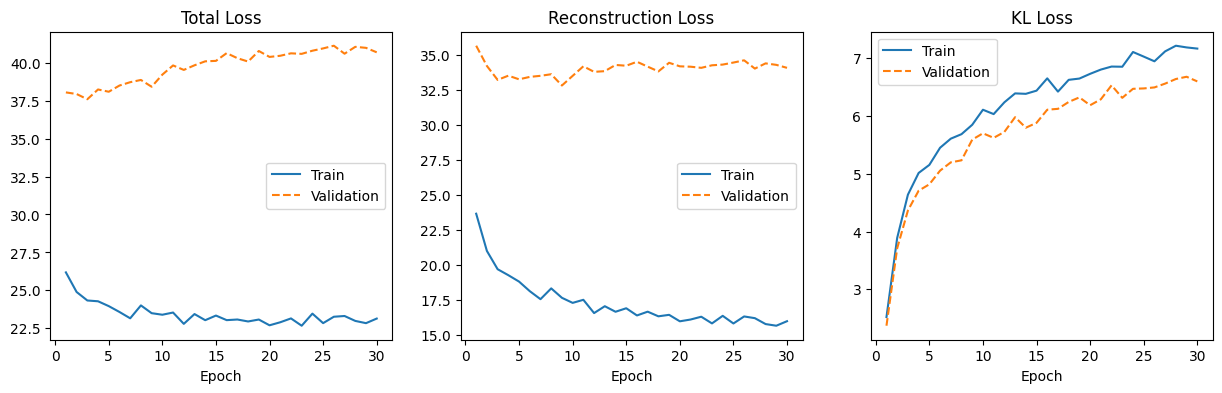

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(
    axes,
    ["loss", "reconstruction_loss", "kl_loss"],
    ["Total Loss", "Reconstruction Loss", "KL Loss"],
):
    ax.plot(epochs_range, history.history[key], label="Train")
    ax.plot(epochs_range, history.history[f"val_{key}"], label="Validation", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

In [12]:
plt.tight_layout()
plt.savefig("words_loss_curves.png", dpi=120)
plt.show()
print("Loss curves saved to words_loss_curves.png")

<Figure size 640x480 with 0 Axes>

Loss curves saved to words_loss_curves.png


In [13]:
# ---------------------------------------------------------------------------
# Sample random words from the prior
# ---------------------------------------------------------------------------
print("\n--- 30 randomly generated words ---")
z_random = np.random.normal(size=(30, LATENT_DIM)).astype("float32")
generated = vae.decoder.predict(z_random, verbose=0)  # (30, MAX_LEN, VOCAB_SIZE)
for i, g in enumerate(generated):
    word = decode_output(g)
    print(f"  {i+1:2d}: {word}")


--- 30 randomly generated words ---
   1: stringey
   2: mitrotiones
   3: antirolite
   4: antoranle
   5: disterious
   6: epentisl
   7: brastelote
   8: hypororphic
   9: polacomenti
  10: demilictle
  11: g
  12: sandish
  13: overtint
  14: retiale
  15: peerosthrou
  16: reanffection
  17: acenoshrric
  18: tand
  19: phemast
  20: promote
  21: aurocorrus
  22: cherterosd
  23: canana
  24: pardinic
  25: parminolice
  26: hoter
  27: congulen
  28: tardana
  29: overhore
  30: santerorahip


In [14]:
# ---------------------------------------------------------------------------
# Interpolation between two real words
# ---------------------------------------------------------------------------
word_a, word_b = "dragon", "castle"
za = vae.encoder.predict(
    np.array([encode_word(word_a)], dtype="float32"), verbose=0
)[0]  # z_mean
zb = vae.encoder.predict(
    np.array([encode_word(word_b)], dtype="float32"), verbose=0
)[0]

In [15]:
steps = 8
print(f"\n--- Latent interpolation: '{word_a}' → '{word_b}' ---")
for t in np.linspace(0, 1, steps):
    z_interp = (1 - t) * za + t * zb
    out = vae.decoder.predict(z_interp[np.newaxis], verbose=0)[0]
    print(f"  t={t:.2f}  →  {decode_output(out)}")


--- Latent interpolation: 'dragon' → 'castle' ---


ValueError: as_list() is not defined on an unknown TensorShape.

/Users/aydin/Documents/Code/mnist_vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/aydin/Documents/Code/mnist_vae/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


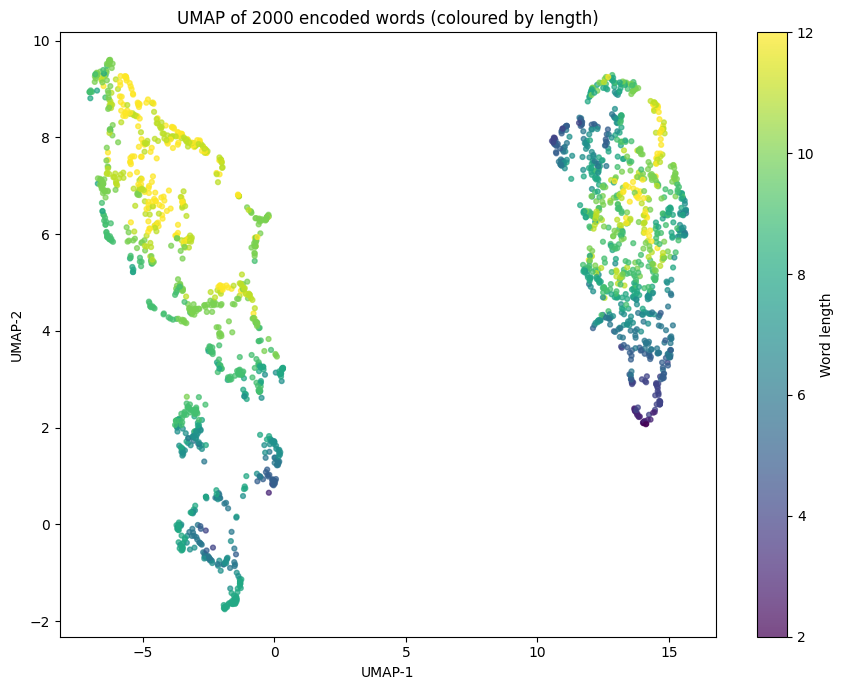

UMAP plot saved to words_umap.png


In [16]:
# ---------------------------------------------------------------------------
# Latent space visualisation with UMAP (sample 2000 words)
# ---------------------------------------------------------------------------
try:
    import umap

    n_sample = min(2000, len(x_val))
    indices = np.random.choice(len(x_val), n_sample, replace=False)
    x_sample = x_val[indices]

    z_mean, _, _ = vae.encoder.predict(x_sample, verbose=0)

    # Colour by word length (easy proxy label)
    word_lengths = np.array([len(decode_output(x_words[split + i])) for i in indices])

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
    z_2d = reducer.fit_transform(z_mean)

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=word_lengths, cmap="viridis", s=12, alpha=0.7)
    plt.colorbar(sc, ax=ax, label="Word length")
    ax.set_title(f"UMAP of {n_sample} encoded words (coloured by length)")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    plt.tight_layout()
    plt.savefig("words_umap.png", dpi=120)
    plt.show()
    print("UMAP plot saved to words_umap.png")
except ImportError:
    print("umap-learn not installed — skipping UMAP visualisation")

In [17]:
# ---------------------------------------------------------------------------
# Save model
# ---------------------------------------------------------------------------
vae.save("vae_words.keras")
print("\nModel saved: vae_words.keras")


Model saved: vae_words.keras


/Users/aydin/Documents/Code/mnist_vae/.venv/lib/python3.13/site-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)
